# Zhongli Air Quality Data Analysis
**Student ID:** 11570016  
**Dataset:** `zhongli_aq_2025.csv`  
**Analysis:** Data inspection, QA/QC, descriptive statistics, and NO2 visualization.

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-h5yurbsf because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Rows: 168
Columns: 8


,datetime,station,PM2.5,O3,NO2,TEMP,RH,WS
0,2025-01-01 00:00:00,Zhongli,14.3,24.8,20.8,13.0,78.5,1.6
1,2025-01-01 01:00:00,Zhongli,13.3,25.9,21.6,14.0,75.3,3.6
2,2025-01-01 02:00:00,Zhongli,9.1,15.4,27.2,13.0,97.9,1.2
3,2025-01-01 03:00:00,Zhongli,14.0,18.9,29.8,13.2,81.4,1.0
4,2025-01-01 04:00:00,Zhongli,13.9,6.6,27.8,13.4,79.0,1.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  168 non-null    object 
 1   station   168 non-null    object 
 2   PM2.5     167 non-null    float64
 3   O3        168 non-null    float64
 4   NO2       168 non-null    float64
 5   TEMP      168 non-null    float64
 6   RH        168 non-null    float64
 7   WS        168 non-null    float64
dtypes: float64(6), object(2)
memory usage: 10.6+ KB

Missing values
datetime    0
station     0
PM2.5       1
O3          0
NO2         0
TEMP        0
RH          0
WS          0
dtype: int64

Invalid values (-9999)
PM2.5    1
O3       1
NO2      0
dtype: int64

Negative values
PM2.5    2
O3       1
NO2      0
dtype: int64


,PM2.5,O3,NO2,TEMP,RH,WS
count,165.00,167.00,168.00,168.00,168.00,168.00
mean,25.45,31.68,19.95,16.97,70.41,1.61
std,14.90,13.45,5.28,3.10,11.29,0.63
min,5.30,6.60,7.90,11.30,47.30,0.30
25%,19.20,19.05,15.75,14.00,60.38,1.10
50%,23.90,31.60,19.45,17.05,70.80,1.60
75%,31.00,44.45,24.00,19.52,79.82,1.90
max,185.00,56.90,33.30,23.40,97.90,3.60


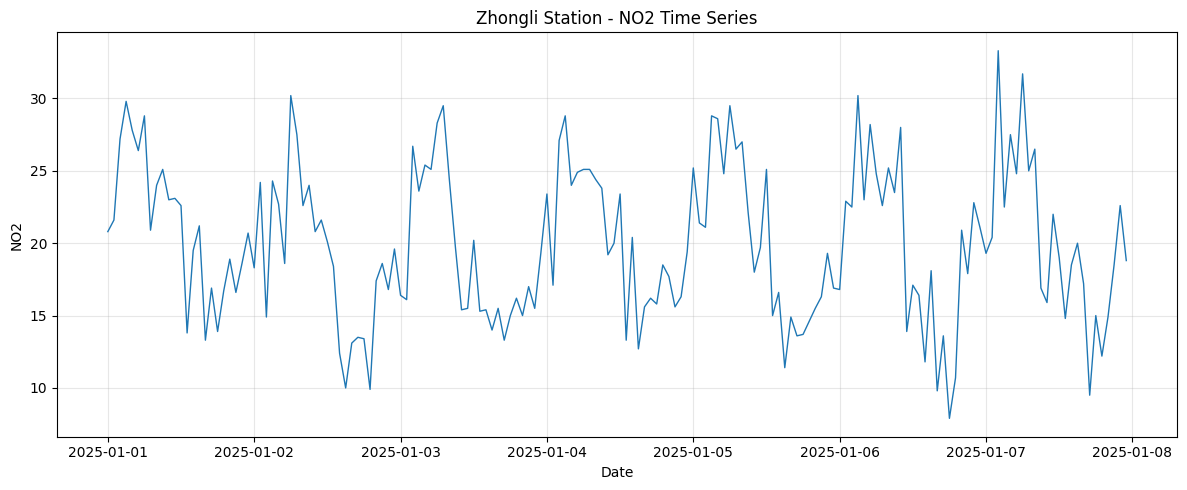

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display


# 1. Read CSV
paths = [
    Path("../data/zhongli_aq_2025.csv"),   # JupyterLab: notebook in notebooks/
    Path("data/zhongli_aq_2025.csv"),      # JupyterLab: repository root
    Path("zhongli_aq_2025.csv"),           # Colab: uploaded file
    Path("/content/zhongli_aq_2025.csv")   # Colab default folder
]

DATA_PATH = next((p for p in paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if "zhongli_aq_2025.csv" not in uploaded:
            raise FileNotFoundError("Please upload zhongli_aq_2025.csv")
        DATA_PATH = Path("zhongli_aq_2025.csv")
    except ImportError:
        raise FileNotFoundError(
            "Cannot find zhongli_aq_2025.csv. "
            "Run from notebooks/ or place the CSV in the current folder."
        )

df = pd.read_csv(
    DATA_PATH,
    encoding="utf-8",
    na_values=["-", "", " ", "NaN"]
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())
df.info()


# 2. QA/QC
pollutants = ["PM2.5", "O3", "NO2"]

print("\nMissing values")
print(df.isna().sum())

print("\nInvalid values (-9999)")
print((df[pollutants] == -9999).sum())

print("\nNegative values")
print((df[pollutants] < 0).sum())


# 3. Data cleaning
df_clean = df.copy()

df_clean[pollutants] = df_clean[pollutants].replace(
    -9999, float("nan")
)

for pollutant in pollutants:
    df_clean.loc[
        df_clean[pollutant] < 0,
        pollutant
    ] = float("nan")


# 4. Descriptive statistics
variables = ["PM2.5", "O3", "NO2", "TEMP", "RH", "WS"]

display(
    df_clean[variables]
    .describe()
    .round(2)
)


# 5. Datetime
df_clean["datetime"] = pd.to_datetime(df_clean["datetime"])
df_clean = df_clean.sort_values("datetime")


# 6. NO2 time-series plot
plt.figure(figsize=(12, 5))

plt.plot(
    df_clean["datetime"],
    df_clean["NO2"],
    linewidth=1
)

plt.title("Zhongli Station - NO2 Time Series")
plt.xlabel("Date")
plt.ylabel("NO2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()